# Residencial


In [1]:
%matplotlib inline
import pandas as pd
from src.data_loader import _load_google_sheet_residencial, _load_google_sheet_consumo, _load_google_sheet_stock, _load_google_sheet_llegadas
from src.limpieza import limpiar_ordenes_compra
from prophet import Prophet
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt 

2026-02-27 12:28:57.338 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
C:\Users\m.fernandez_fluxsola\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# funciones

In [2]:
df = _load_google_sheet_llegadas()

2026-02-27 12:28:58.375 
'server.enableXsrfProtection=true'.
As a result, 'server.enableCORS' is being overridden to 'true'.

More information:
In order to protect against CSRF attacks, we send a cookie with each request.
To do so, we must specify allowable origins, which places a restriction on
cross-origin resource sharing.

If cross origin resource sharing is required, please disable server.enableXsrfProtection.
            


--- Conectando a Google Sheets API para llegadas ---


In [5]:
limpiar_ordenes_compra(df).head(20)

,Número de documento,Fecha de contabilización,Nombre de cliente/proveedor,Número de artículo,Descripción artículo/serv.,Familia_Articulo,SubFamilia,Cantidad,Precio_Unitario,Total_Linea,Cantidad abierta restante,Total_Pendiente,Fecha de entrega de la línea,Status de la línea,Creador,Comentarios,Numerador,Número de línea
10,"1,00E+08",2025-07-11,EMAT SPA,EXI-007046,"Huawei, Backup Box-B0, Monofásico, para sistem...",EQUIPOS PRINCIPALES,,1.0,480000.0,0.0,0.0,480000,NaT,C,Pablo Fernandez,Solicitud realizada por - Gabriela Elizabeth A...,17236,
11,"1,00E+08",2025-08-20,DISTRIBUIDORA TECNICA ELECTRICA VITEL S.A.,EXI-008838,Dlg Modulo Wifi Bateria Soluna HV Wifi Stick,EQUIPOS PRINCIPALES,ACCESORIOS,5.0,50915.0,0.0,0.0,254575,NaT,C,Pablo Fernandez,Se solicitan equipos para poder trabajar con s...,18623,
12,"1,00E+08",2025-07-30,EMAT SPA,EXI-000414,Datamanager 2.0 Wlan Galsymprim Tarjeta,EQUIPOS PRINCIPALES,,1.0,260890.0,0.0,0.0,260890,NaT,C,Daniela Valderrama,Solicitud realizada por - Daniel Elias Mendoza...,17896,
13,"1,00E+08",2025-10-09,EMAT SPA,EXI-006236,Huawei Smart Dongle Wlan - Fe,EQUIPOS PRINCIPALES,ACCESORIOS,1.0,60761.0,0.0,0.0,60761,NaT,C,Pablo Fernandez,AUTORIZADO POR FERNANDO CASTILLO RETURO EQUIPO...,20420,
14,"1,00E+08",2025-10-09,EMAT SPA,EXI-006236,Huawei Smart Dongle Wlan - Fe,EQUIPOS PRINCIPALES,ACCESORIOS,1.0,60761.0,0.0,0.0,60761,NaT,C,Pablo Fernandez,AUTORIZADO POR FERNANDO CASTILLO RETURO EQUIPO...,20420,1
16,"1,00E+08",2026-01-05,KACO NEW ENERGY GMBH,EXI-008404,Kaco Blueplanet 165 TL3 M1 WM OD IIQ0 Garantia,EQUIPOS PRINCIPALES,,1.0,1.0,0.0,0.0,1058,NaT,C,Constanza Robledo,garantia kako AWB 9762622376,23816,
25,"1,00E+08",2025-07-23,COPEC VOLTEX SPA,EXI-009394,Sistema De Gestión De Carga trífasico,EQUIPOS PRINCIPALES,CARGADORES,1.0,144162.0,0.0,1.0,144162,NaT,O,Pablo Fernandez,"RVDIC-870, etapa RE-EJE SOLICITADO POR DIEGO C...",17668,3
26,"1,00E+08",2025-07-23,COPEC VOLTEX SPA,EXI-009393,Cargador Pulsar Plus Tipo 2 Voltex Wallbox 22kW,EQUIPOS PRINCIPALES,CARGADORES,1.0,488247.0,0.0,1.0,488247,NaT,O,Pablo Fernandez,"RVDIC-870, etapa RE-EJE SOLICITADO POR DIEGO C...",17668,2
28,"1,00E+08",2025-08-11,INGENIERIA INPOWER SPA,EXI-003662,Janitza Umg 604-Pro 230V Power Analyzer,EQUIPOS PRINCIPALES,,1.0,1090000.0,0.0,0.0,1090000,NaT,C,Marieanne Rangel,Según la cotización Cot. Nr. 1485 rev. A. Soli...,18330,
29,"1,00E+08",2025-09-05,IMPORTADORA Y DISTRIBUIDORA TASCO CHILE,EXI-009199,Kit Unión De Gabinetes,EQUIPOS PRINCIPALES,,1.0,29083.0,0.0,0.0,29083,NaT,C,Marieanne Rangel,ITEM 1: PARA GABINETES DE 2000x800x600 QUADRIT...,19263,


In [2]:

# --- 1. FUNCIÓN DE PREPARACIÓN DE DATOS ---
def preparar_datos_prophet(df_input, col_metrica):
    """
    Toma el DF con índice de fecha y lo convierte al formato 'ds', 'y' de Prophet.
    """
    df = df_input.copy()
    
    # Reset index para tener la fecha como columna y filtrar columnas
    df_prophet = df.reset_index()[['Fecha de ganado', col_metrica]]
    df_prophet.columns = ['ds', 'y']
    
    return df_prophet

# --- 2. FUNCIÓN DE ENTRENAMIENTO Y PREDICCIÓN ---
def ejecutar_forecast(df_train, meses_futuros=4, **params_modelo):
    """
    Configura, entrena y genera la predicción.
    **params_modelo: Permite pasar cualquier parámetro de Prophet (ej. seasonality_mode)
    """
    # 1. Configuración del modelo con los parámetros recibidos
    m = Prophet(**params_modelo)
    
    # 2. Agregados fijos (Feriados CL)
    m.add_country_holidays(country_name='CL')
    
    # 3. Entrenamiento
    m.fit(df_train)
    
    # 4. Creación del futuro
    future = m.make_future_dataframe(periods=meses_futuros, freq='ME')
    
    # 5. Predicción
    forecast = m.predict(future)
    
    return m, forecast

# --- 3. FUNCIÓN DE VISUALIZACIÓN (DASHBOARD) ---
def visualizar_performance(model, df_train, forecast, titulo_metrica="Proyectos"):
    """
    Genera los dos gráficos clave: Predicción Futura y Calidad del Ajuste.
    """
    # --- Gráfica A: Prophet Standard (Futuro) ---
    print(f"--- Pronóstico de {titulo_metrica} (Futuro) ---")
    fig1 = model.plot(forecast)
    plt.show()

    # --- Gráfica B: Real vs Modelo (Calidad Ajuste) ---
    print(f"--- Calidad del Ajuste: Real vs Modelo ({titulo_metrica}) ---")
    
    # Cruce de datos
    performance = pd.merge(df_train, forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']], on='ds')

    plt.figure(figsize=(12, 6))
    
    # Datos Reales
    plt.plot(performance['ds'], performance['y'], 'ko', label='Datos Reales')
    # Modelo
    plt.plot(performance['ds'], performance['yhat'], 'b-', linewidth=2, label='Ajuste Modelo')
    # Incertidumbre
    plt.fill_between(performance['ds'], performance['yhat_lower'], performance['yhat_upper'], 
                     color='blue', alpha=0.1, label='Incertidumbre')

    plt.title(f'Validación de Entrenamiento: {titulo_metrica}')
    plt.xlabel('Fecha')
    plt.ylabel(titulo_metrica)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Retornar tabla resumen
    return forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10)



In [3]:
df = _load_google_sheet_residencial()
# 2. Asegurar formato de fecha
df['Fecha de ganado'] = pd.to_datetime(df['Fecha de ganado'])

# 3. Tratar los nulos en Baterías (kWh)
# Si es nulo, asumimos que es 0 (no tiene batería) para poder sumar
df['kWh'] = df['kWh'].fillna(0)

hoy = pd.Timestamp.now().normalize()
principio_mes = hoy.replace(day=1)

df = df[df['Fecha de ganado'] < principio_mes ]

# 4. LA MAGIA: Resampling (Agrupación Temporal)
# Convertimos el DataFrame para que el índice sea la fecha
df = df.sort_values('Fecha de ganado')
df_temporal = df.set_index('Fecha de ganado')

# Agrupamos por Mes ('ME' = Month End)
# Calculamos: Cantidad de proyectos, Suma de kWp y Suma de kWh
df_ventas_mensual = df_temporal.resample('ME').agg({
    'CeCo': 'count',       # Cantidad de proyectos vendidos
    'kWp': 'sum',          # Total potencia vendida
    'kWh': 'sum'           # Total capacidad batería vendida
})

# Renombramos para claridad
df_ventas_mensual.columns = ['Cantidad_Proyectos', 'Total_kWp', 'Total_kWh']

# Visualizar la historia
print(df_ventas_mensual.tail()) # Ver los últimos meses

2026-02-06 12:18:07.069 
'server.enableXsrfProtection=true'.
As a result, 'server.enableCORS' is being overridden to 'true'.

More information:
In order to protect against CSRF attacks, we send a cookie with each request.
To do so, we must specify allowable origins, which places a restriction on
cross-origin resource sharing.

If cross origin resource sharing is required, please disable server.enableXsrfProtection.
            


--- Conectando a Google Sheets API para Residencial ---
                 Cantidad_Proyectos  Total_kWp  Total_kWh
Fecha de ganado                                          
2025-09-30                       84    530.025      155.0
2025-10-31                       87    581.775      204.0
2025-11-30                       81    513.055      110.0
2025-12-31                       65    470.795      165.0
2026-01-31                       48    310.680      105.0


# media movil

In [11]:
# Crea una columna de predicción simple (Promedio de los últimos 3 meses)
df_ventas_mensual['Prediccion_VENTA'] = df_ventas_mensual['Cantidad_Proyectos'].rolling(window=3).mean().shift(1)

# Prophet

13:49:29 - cmdstanpy - INFO - Chain [1] start processing
13:49:30 - cmdstanpy - INFO - Chain [1] done processing


--- Pronóstico de Cantidad Proyectos (Futuro) ---


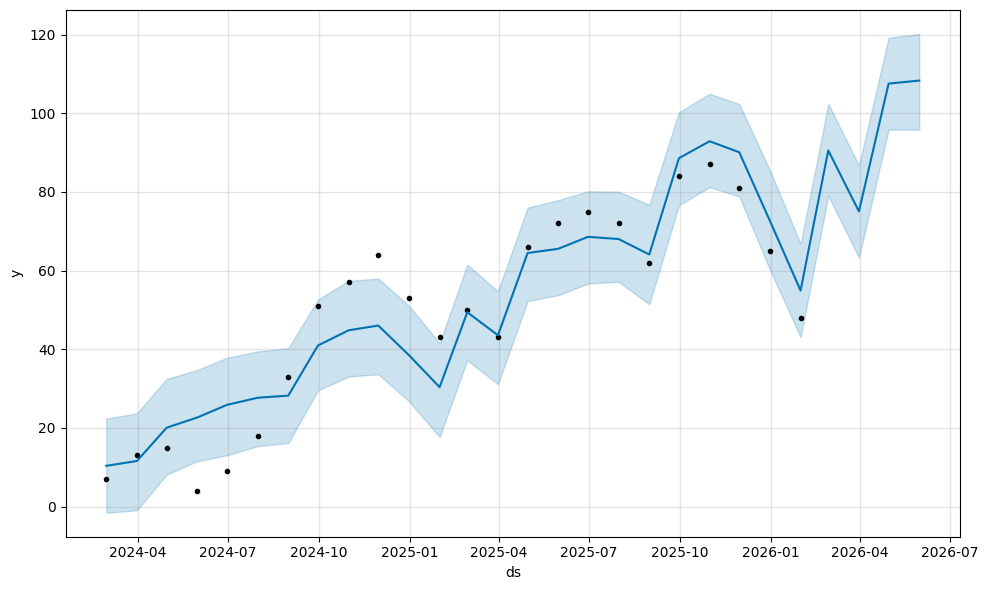

--- Calidad del Ajuste: Real vs Modelo (Cantidad Proyectos) ---


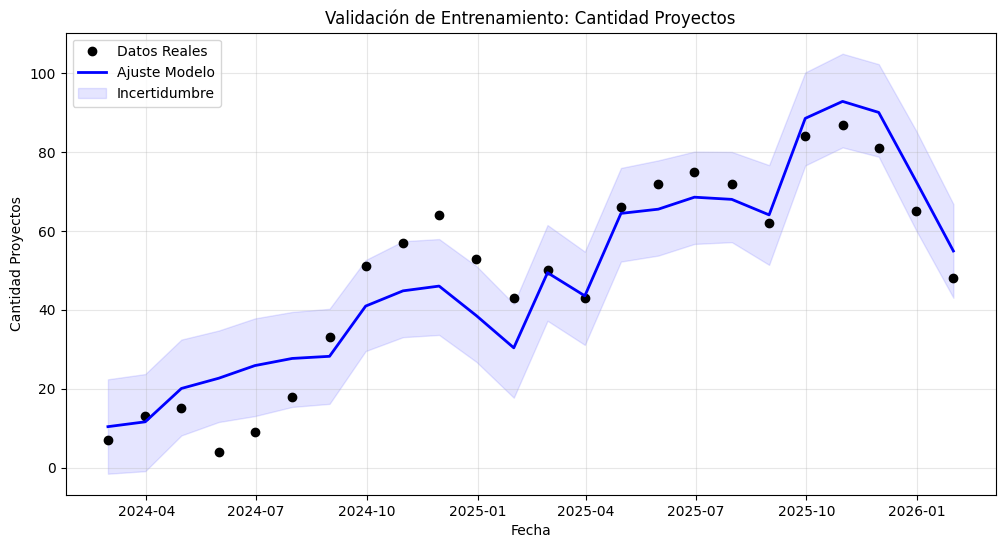

,ds,yhat,yhat_lower,yhat_upper
18,2025-08-31,64.094466,51.409718,76.718712
19,2025-09-30,88.578470,76.631087,100.229186
20,2025-10-31,92.884951,81.214856,104.980509
21,2025-11-30,90.090346,78.853591,102.334207
22,2025-12-31,72.648002,60.230421,85.495679
23,2026-01-31,54.933824,43.058578,66.841969
24,2026-02-28,90.553829,79.011064,102.414849
25,2026-03-31,75.049101,63.288196,86.758863
26,2026-04-30,107.547342,95.851924,119.206000
27,2026-05-31,108.314352,95.809334,120.170972


In [10]:
# ==========================================
#  EJECUCIÓN (ASÍ USAS TU CÓDIGO AHORA)
# ==========================================

# 1. Preparar Datos
df_listo = preparar_datos_prophet(df_ventas_mensual, 'Cantidad_Proyectos')

# 2. Configurar Parámetros (Aquí es donde ajustas las perillas fácilmente)
parametros = {
    'seasonality_mode': 'multiplicative',
    'changepoint_prior_scale': 0.05,  # Flexibilidad de la tendencia
    'seasonality_prior_scale': 1.0,   # Fuerza de la estacionalidad (ajustado para evitar overfitting)
    'interval_width': 0.8,            # Ancho del cono de incertidumbre
    'yearly_seasonality': True        # Forzar ciclo anual
}

# 3. Correr el Modelo
modelo, prediccion = ejecutar_forecast(df_listo, meses_futuros=4, **parametros)

# 4. Ver Resultados
tabla_final = visualizar_performance(modelo, df_listo, prediccion, "Cantidad Proyectos")
display(tabla_final)

# Prueba

In [18]:
# Supongamos que df_ventas_mensual es tu tabla con índice de fecha y columna 'Total_kWp'
data = df_ventas_mensual.copy()

# --- PASO 1: DIVIDIR DATOS ---
# Usamos todos los datos MENOS los últimos 3 meses para entrenar
train = data.iloc[:-3] 
# Usamos los últimos 3 meses para validar (la "verdad")
test = data.iloc[-3:]  

# --- MODELO A: MEDIA MÓVIL (Simple) ---
# Calculamos el promedio de los últimos 3 meses conocidos en el set de entrenamiento
prediccion_ma = train['Total_kWp'].rolling(window=3).mean().iloc[-1]
# Creamos una lista con ese mismo valor repetido 3 veces (es una línea plana)
preds_ma = [prediccion_ma] * 3

# --- MODELO B: PROPHET (Complejo) ---
# Preparamos datos para Prophet
df_prophet = train.reset_index()[['Fecha de ganado', 'Total_kWp']]
df_prophet.columns = ['ds', 'y']

m = Prophet()
m.fit(df_prophet)

# Creamos las fechas futuras (los 3 meses del test)
future = m.make_future_dataframe(periods=3, freq='M')
forecast = m.predict(future)
# Sacamos solo los últimos 3 valores
preds_prophet = forecast['yhat'].tail(3).values

# --- PASO 3: COMPARAR ERRORES (MAE) ---
# MAE: Mean Absolute Error (En promedio, ¿por cuántos kWp me equivoqué?)
error_ma = mean_absolute_error(test['Total_kWp'], preds_ma)
error_prophet = mean_absolute_error(test['Total_kWp'], preds_prophet)

print(f"Error Promedio (MAE) Media Móvil: {error_ma:.2f} kWp")
print(f"Error Promedio (MAE) Prophet:     {error_prophet:.2f} kWp")

if error_prophet < error_ma:
    print("🏆 Ganador: Prophet")
else:
    print("🏆 Ganador: Media Móvil (A veces lo simple es mejor)")

12:09:10 - cmdstanpy - INFO - Chain [1] start processing
12:09:10 - cmdstanpy - INFO - Chain [1] done processing


Error Promedio (MAE) Media Móvil: 79.97 kWp
Error Promedio (MAE) Prophet:     175.83 kWp
🏆 Ganador: Media Móvil (A veces lo simple es mejor)


C:\Users\m.fernandez_fluxsola\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\prophet\forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(
